# Python Seminar #7：Lasso回帰と適用ドメイン（Applicability Domain）

`boston.csv` の `MEDV` を目的変数として Lasso 回帰モデルを構築し、Hold-Out 法で分けたテストデータが適用ドメイン（AD）の内側か外側かを k 近傍法で判定する。

## 実施内容

1. Boston Housing データの読み込みと確認
2. 学習データとテストデータへの分割（80:20）
3. Lasso 回帰モデルの構築、正則化強度の選択、予測性能の評価
4. 学習データだけを用いた kNN 距離と AD 閾値の算出
5. テストデータの AD 内外判定
6. kNN 距離と予測誤差の関係、および AD 内外別の予測結果の可視化

### AD の定義

- 距離空間：学習データの平均・標準偏差で標準化した13特徴量の空間
- 距離尺度：ユークリッド距離
- 近傍数：$k=5$
- 閾値：学習データ間の5近傍平均距離の **95パーセンタイル**
- 判定：平均距離が閾値以下なら AD 内、閾値を超えれば AD 外

学習データ自身の近傍距離を計算するときは、自分自身（距離0）を除外する。


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
K = 5
PERCENTILE = 95

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")


Python: 3.11.15
pandas: 3.0.3
scikit-learn: 1.8.0


## 1. データの読み込みと確認

CSV の1列目はサンプル名なのでインデックスとして読み込む。目的変数は `MEDV`、残りの13列を説明変数とする。

In [2]:
data_path = Path("boston.csv")
if not data_path.exists():
    raise FileNotFoundError(f"データファイルが見つかりません: {data_path.resolve()}")

df = pd.read_csv(data_path, index_col=0)

print(f"データ形状: {df.shape[0]} samples × {df.shape[1]} columns")
print(f"欠損値数: {int(df.isna().sum().sum())}")
print(f"重複したサンプル名数: {int(df.index.duplicated().sum())}")
display(df.head())

データ形状: 506 samples × 14 columns
欠損値数: 0
重複したサンプル名数: 0


,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
sample_1,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
sample_2,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
sample_3,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
sample_4,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
sample_5,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [3]:
display(df.describe().T.round(3))

if "MEDV" not in df.columns:
    raise KeyError("目的変数 MEDV が見つかりません。")
if not all(pd.api.types.is_numeric_dtype(dtype) for dtype in df.dtypes):
    raise TypeError("数値型ではない列が含まれています。")
if df.isna().any().any():
    raise ValueError("欠損値が含まれています。前処理方法を決めてから分析してください。")

,count,mean,std,min,25%,50%,75%,max
MEDV,506.0,22.533,9.197,5.000,17.025,21.200,25.000,50.000
CRIM,506.0,3.614,8.602,0.006,0.082,0.257,3.677,88.976
ZN,506.0,11.364,23.322,0.000,0.000,0.000,12.500,100.000
INDUS,506.0,11.137,6.860,0.460,5.190,9.690,18.100,27.740
CHAS,506.0,0.069,0.254,0.000,0.000,0.000,0.000,1.000
NOX,506.0,0.555,0.116,0.385,0.449,0.538,0.624,0.871
RM,506.0,6.285,0.703,3.561,5.885,6.208,6.624,8.780
AGE,506.0,68.575,28.149,2.900,45.025,77.500,94.075,100.000
DIS,506.0,3.795,2.106,1.130,2.100,3.207,5.188,12.126
RAD,506.0,9.549,8.707,1.000,4.000,5.000,24.000,24.000


## 2. Hold-Out 分割と Lasso 回帰モデル

データを学習80%、テスト20%に固定乱数で分割する。Lasso は係数の絶対値にペナルティを課す線形回帰であり、不要な特徴量の係数を0にできる。

Lasso は特徴量のスケールに影響されるため、学習データから求めた平均と標準偏差で説明変数を標準化する。`LassoCV` の5-fold交差検証により正則化強度 $\alpha$ を選び、独立したテストデータで性能を評価する。AD の構築には目的変数 `MEDV` を使わず、説明変数だけを使う。


In [4]:
X = df.drop(columns="MEDV")
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"学習データ: {X_train.shape}")
print(f"テストデータ: {X_test.shape}")

学習データ: (404, 13)
テストデータ: (102, 13)


In [5]:
# Lasso用の標準化：学習データでfitし、テストデータにはtransformのみを適用する。
model_scaler = StandardScaler()
X_train_model_scaled = model_scaler.fit_transform(X_train)
X_test_model_scaled = model_scaler.transform(X_test)

# 学習データ内の5-fold交差検証でalphaを選択してLassoモデルを学習する。
model = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=100_000)
model.fit(X_train_model_scaled, y_train)

y_train_pred = model.predict(X_train_model_scaled)
y_pred = model.predict(X_test_model_scaled)

overall_metrics = pd.DataFrame(
    {
        "R2": [r2_score(y_train, y_train_pred), r2_score(y_test, y_pred)],
        "RMSE": [
            mean_squared_error(y_train, y_train_pred) ** 0.5,
            mean_squared_error(y_test, y_pred) ** 0.5,
        ],
        "MAE": [
            mean_absolute_error(y_train, y_train_pred),
            mean_absolute_error(y_test, y_pred),
        ],
    },
    index=["Training samples", "Test samples"],
)

coefficient_table = (
    pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    .assign(Absolute_coefficient=lambda table: table["Coefficient"].abs())
    .sort_values("Absolute_coefficient", ascending=False)
)

print(f"Selected alpha: {model.alpha_:.6f}")
print(f"Non-zero coefficients: {(model.coef_ != 0).sum()} / {X.shape[1]}")
display(overall_metrics.round(3))
display(coefficient_table.round(4))


Selected alpha: 0.006864
Non-zero coefficients: 13 / 13


,R2,RMSE,MAE
Training samples,0.751,4.652,3.307
Test samples,0.668,4.931,3.183


,Feature,Coefficient,Absolute_coefficient
12,LSTAT,-3.6101,3.6101
5,RM,3.1495,3.1495
7,DIS,-3.0337,3.0337
8,RAD,2.1276,2.1276
10,PTRATIO,-2.0250,2.0250
4,NOX,-1.9789,1.9789
9,TAX,-1.6436,1.6436
11,B,1.1214,1.1214
0,CRIM,-0.9830,0.9830
3,CHAS,0.7197,0.7197


## 3. kNN による適用ドメインの構築

説明変数ごとの単位とスケールが異なるため、学習データから求めた平均と標準偏差で標準化する。テストデータにも同じ変換を適用する。

学習サンプル $i$ の AD 距離 $d_i$ を、自己点を除く $k=5$ 個の近傍へのユークリッド距離の平均とする。

$$
d_i = \frac{1}{k}\sum_{j=1}^{k} \lVert \mathbf{x}_i-\mathbf{x}_{N_j(i)} \rVert_2
$$

学習データの $d_i$ の95パーセンタイルを閾値とする。この定義では、学習データの約95%が AD 内になる。

In [6]:
ad_scaler = StandardScaler()
X_train_scaled = ad_scaler.fit_transform(X_train)
X_test_scaled = ad_scaler.transform(X_test)

# 学習データでは自己点を除くため K + 1 点を検索し、距離0の先頭列を除外する。
train_nn = NearestNeighbors(n_neighbors=K + 1, metric="euclidean")
train_nn.fit(X_train_scaled)
train_distances, _ = train_nn.kneighbors(X_train_scaled)
train_mean_distance = train_distances[:, 1:].mean(axis=1)

threshold = np.percentile(train_mean_distance, PERCENTILE)
train_ad_inside = train_mean_distance <= threshold

train_distance_summary = pd.Series(train_mean_distance).describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
)
display(train_distance_summary.to_frame("mean kNN distance").round(4))
print(f"AD threshold ({PERCENTILE}th percentile): {threshold:.4f}")
print(f"学習データのAD内割合: {train_ad_inside.mean():.1%}")


,mean kNN distance
count,404.0000
mean,1.1979
std,0.6111
min,0.4576
50%,1.0503
90%,1.8534
95%,2.3825
99%,3.5922
max,5.4969


AD threshold (95th percentile): 2.3825
学習データのAD内割合: 94.8%


### 学習データ間の平均距離分布と閾値

赤い破線より右側が AD 外に相当する。閾値は95パーセンタイルなので、学習データの上位約5%の疎な領域が AD 外になる。

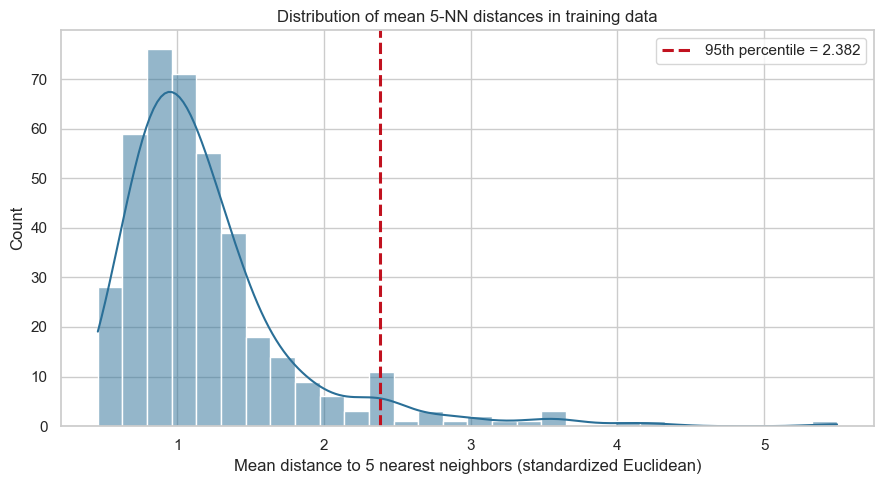

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    train_mean_distance,
    bins=30,
    kde=True,
    color="#2A6F97",
    edgecolor="white",
    ax=ax,
)
ax.axvline(
    threshold,
    color="#C1121F",
    linestyle="--",
    linewidth=2.2,
    label=f"{PERCENTILE}th percentile = {threshold:.3f}",
)
ax.set(
    title=f"Distribution of mean {K}-NN distances in training data",
    xlabel=f"Mean distance to {K} nearest neighbors (standardized Euclidean)",
    ylabel="Count",
)
ax.legend()
plt.tight_layout()
plt.show()

## 4. テストデータの AD 判定

各テストサンプルについて、標準化した学習データの5近傍までの平均距離を計算する。学習データから定めた閾値以下を AD 内、閾値超過を AD 外と判定する。

In [8]:
# テストサンプル自身は学習集合に含まれないため、K点をそのまま使用する。
test_nn = NearestNeighbors(n_neighbors=K, metric="euclidean")
test_nn.fit(X_train_scaled)
test_distances, _ = test_nn.kneighbors(X_test_scaled)
test_mean_distance = test_distances.mean(axis=1)
test_ad_inside = test_mean_distance <= threshold

results = pd.DataFrame(
    {
        "actual_MEDV": y_test,
        "predicted_MEDV": y_pred,
        "absolute_error": np.abs(y_test.to_numpy() - y_pred),
        f"mean_{K}NN_distance": test_mean_distance,
        "AD": np.where(test_ad_inside, "Inside", "Outside"),
    },
    index=y_test.index,
).sort_values(f"mean_{K}NN_distance")

ad_counts = results["AD"].value_counts().reindex(["Inside", "Outside"], fill_value=0)
display(ad_counts.rename("samples").to_frame())
print(f"テストデータのAD内割合: {(results['AD'] == 'Inside').mean():.1%}")
display(results.tail(10).round(3))

,samples
AD,
Inside,99
Outside,3


テストデータのAD内割合: 97.1%


,actual_MEDV,predicted_MEDV,absolute_error,mean_5NN_distance,AD
sample_269,43.5,39.491,4.009,1.641,Inside
sample_376,15.0,25.925,10.925,1.723,Inside
sample_205,50.0,42.502,7.498,1.727,Inside
sample_399,5.0,6.231,1.231,1.783,Inside
sample_210,20.0,16.700,3.300,1.800,Inside
sample_356,20.6,15.768,4.832,1.911,Inside
sample_418,10.4,5.721,4.679,2.016,Inside
sample_413,17.9,-0.180,18.080,2.659,Outside
sample_366,27.5,12.456,15.044,2.746,Outside
sample_415,7.0,-6.013,13.013,3.814,Outside


## 5. AD を利用した予測値の信頼性評価

AD 内外ごとに予測指標を集計する。AD 外のサンプル数が少ない場合、指標は不安定になり得るため、サンプル数と併せて解釈する。

In [9]:
def regression_metrics(group: pd.DataFrame) -> pd.Series:
    actual = group["actual_MEDV"]
    predicted = group["predicted_MEDV"]
    return pd.Series(
        {
            "n": len(group),
            "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
            "RMSE": mean_squared_error(actual, predicted) ** 0.5,
            "MAE": mean_absolute_error(actual, predicted),
        }
    )


metrics_by_ad = (
    results.groupby("AD", sort=False)
    .apply(regression_metrics, include_groups=False)
    .reindex(["Inside", "Outside"])
)
display(metrics_by_ad.round(3))

,n,R2,RMSE,MAE
AD,,,,
Inside,99.0,0.757,4.214,2.814
Outside,3.0,-2.434,15.519,15.379


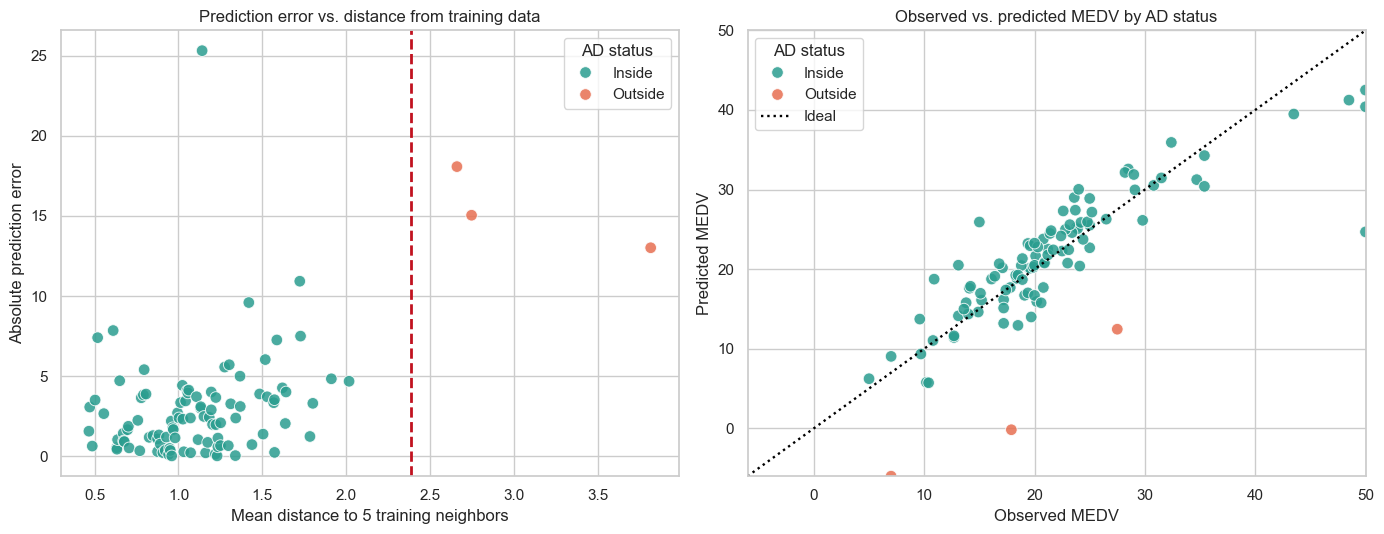

In [10]:
palette = {"Inside": "#2A9D8F", "Outside": "#E76F51"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 指定された可視化：横軸 kNN 平均距離、縦軸 予測の絶対誤差
sns.scatterplot(
    data=results,
    x=f"mean_{K}NN_distance",
    y="absolute_error",
    hue="AD",
    hue_order=["Inside", "Outside"],
    palette=palette,
    s=70,
    alpha=0.85,
    ax=axes[0],
)
axes[0].axvline(threshold, color="#C1121F", linestyle="--", linewidth=2)
axes[0].set(
    title="Prediction error vs. distance from training data",
    xlabel=f"Mean distance to {K} training neighbors",
    ylabel="Absolute prediction error",
)

# 実測値と予測値。AD外の点を別色で示す。
sns.scatterplot(
    data=results,
    x="actual_MEDV",
    y="predicted_MEDV",
    hue="AD",
    hue_order=["Inside", "Outside"],
    palette=palette,
    s=70,
    alpha=0.85,
    ax=axes[1],
)
lims = [
    min(results["actual_MEDV"].min(), results["predicted_MEDV"].min()),
    max(results["actual_MEDV"].max(), results["predicted_MEDV"].max()),
]
axes[1].plot(lims, lims, color="black", linestyle=":", linewidth=1.7, label="Ideal")
axes[1].set(
    title="Observed vs. predicted MEDV by AD status",
    xlabel="Observed MEDV",
    ylabel="Predicted MEDV",
    xlim=lims,
    ylim=lims,
)

for ax in axes:
    ax.legend(title="AD status")

plt.tight_layout()
plt.show()

## 6. 結果の要約

次のセルでは、実際に得られた数値から結論文を生成する。

In [11]:
inside = results[results["AD"] == "Inside"]
outside = results[results["AD"] == "Outside"]

test_metrics = overall_metrics.loc["Test samples"]

print("【分析条件】")
print(f"- 回帰モデル: LassoCV（5-fold CV）、選択された alpha = {model.alpha_:.6f}")
print(f"- 非ゼロ係数: {int((model.coef_ != 0).sum())} / {X.shape[1]}")
print(f"- 距離空間: 学習データで標準化した{X.shape[1]}特徴量空間")
print(f"- 距離尺度: Euclidean、k = {K}")
print(f"- 閾値: 学習データ平均距離の{PERCENTILE}パーセンタイル = {threshold:.4f}")
print()
print("【結果】")
print(
    f"- テスト{len(results)}件のうち、AD内は{len(inside)}件 "
    f"({len(inside) / len(results):.1%})、AD外は{len(outside)}件 "
    f"({len(outside) / len(results):.1%})。"
)
print(
    f"- テスト全体の性能は R2={test_metrics['R2']:.3f}, "
    f"RMSE={test_metrics['RMSE']:.3f}, MAE={test_metrics['MAE']:.3f}。"
)
if len(inside):
    print(f"- AD内の MAE は {inside['absolute_error'].mean():.3f}。")
if len(outside):
    print(f"- AD外の MAE は {outside['absolute_error'].mean():.3f}。")
    if len(inside) and outside["absolute_error"].mean() > inside["absolute_error"].mean():
        print("- この分割ではAD外の平均誤差がAD内より大きく、AD判定が低信頼予測の識別に寄与した。")
    elif len(inside):
        print("- この分割ではAD外の平均誤差はAD内より大きくなかった。AD外サンプル数も考慮し、別分割や交差検証で安定性を確認する必要がある。")


【分析条件】
- 回帰モデル: LassoCV（5-fold CV）、選択された alpha = 0.006864
- 非ゼロ係数: 13 / 13
- 距離空間: 学習データで標準化した13特徴量空間
- 距離尺度: Euclidean、k = 5
- 閾値: 学習データ平均距離の95パーセンタイル = 2.3825

【結果】
- テスト102件のうち、AD内は99件 (97.1%)、AD外は3件 (2.9%)。
- テスト全体の性能は R2=0.668, RMSE=4.931, MAE=3.183。
- AD内の MAE は 2.814。
- AD外の MAE は 15.379。
- この分割ではAD外の平均誤差がAD内より大きく、AD判定が低信頼予測の識別に寄与した。


## 7. 考察

- Lasso は線形モデルであり、係数の縮小と変数選択によって過学習を抑える一方、強い非線形関係は直接表現できない。
- AD はモデルの予測精度そのものではなく、テストサンプルが学習データの特徴量空間にどの程度近いかを表す指標である。
- AD 外の予測は外挿に近くなるため、数値だけをそのまま採用せず、追加データの収集や個別確認を優先する判断材料になる。
- 今回の閾値（95パーセンタイル）と $k=5$ は分析者が定めた条件である。用途に応じて、90/95/99パーセンタイルや複数の $k$ で結果の頑健性を確認するとよい。
- Hold-Out の1回の分割だけでは AD 外のサンプル数が少なくなることがある。より安定した評価には、反復 Hold-Out や交差検証を組み合わせる方法が考えられる。
